In [2]:
import sys
from pathlib import Path

import sys
sys.path.insert(0, '/app')
%load_ext autoreload
%autoreload 2
%reload_ext autoreload


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, List
from features.f_cto_line import cto_line

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

%matplotlib inline

In [3]:
BUNDLE_PATH = '/data/bundle/etf_x_list_features_bundle.parquet'

df_bundle = pd.read_parquet(BUNDLE_PATH)
print(f"Bundle shape: {df_bundle.shape}")
print(f"Bundle columns: {df_bundle.columns.tolist()[:10]}...")

def get_etf_symbols(df: pd.DataFrame) -> List[str]:
    symbols = set()
    for col in df.columns:
        if '_S_close_f32' in col:
            symbols.add(col.split('_')[0])
    return sorted(symbols)

etf_symbols = get_etf_symbols(df_bundle)
print(f"ETFs found: {etf_symbols}")

Bundle shape: (37946, 171)
Bundle columns: ['QQQ_S_open_f32', 'QQQ_S_high_f32', 'QQQ_S_low_f32', 'QQQ_S_close_f32', 'QQQ_S_volume_f64', 'QQQ_S_open_time_i', 'QQQ_S_close_time_i', 'QQQ_minute_diff', 'QQQ_gap_flag', 'QQQ_valid_row']...
ETFs found: ['GDX', 'GLD', 'QQQ', 'SHV', 'SPY', 'TLT', 'VWO', 'XLB', 'XLE', 'XME']


In [3]:
def convert_prefixed_to_ohlcv(df: pd.DataFrame, symbol: str) -> pd.DataFrame:
    ohlcv_df = pd.DataFrame(index=df.index)
    
    ohlcv_df['Close'] = df[f'{symbol}_S_close_f32']
    ohlcv_df['Open'] = df[f'{symbol}_S_open_f32']
    ohlcv_df['High'] = df[f'{symbol}_S_high_f32']
    ohlcv_df['Low'] = df[f'{symbol}_S_low_f32']
    ohlcv_df['Volume'] = df[f'{symbol}_S_volume_f64']
    
    if 'i_minute_i' in df.columns:
        base = pd.Timestamp('2000-01-01')
        ohlcv_df.index = base + pd.to_timedelta(df['i_minute_i'].astype(int), unit='m')
    
    return ohlcv_df.dropna()

def run_cto_strategy(df: pd.DataFrame, params: Tuple[int, int, int, int]) -> pd.DataFrame:
    df = df.copy()
    df = cto_line(df, p_param=params, isnum=True)
    
    df['Signal'] = df['color']
    df['Returns'] = df['Signal'].shift(1) * df['Close'].pct_change()
    
    return df

def calculate_sharpe(returns: pd.Series, periods_per_year: int = 252 * 7) -> float:
    returns = returns.dropna()
    if len(returns) == 0 or returns.std() == 0:
        return np.nan
    
    mean_return = returns.mean()
    std_return = returns.std()
    
    annualized_return = mean_return * periods_per_year
    annualized_std = std_return * np.sqrt(periods_per_year)
    
    sharpe = annualized_return / annualized_std if annualized_std > 0 else 0
    return sharpe

In [4]:
X_RANGE = range(75, 5000, 25)
Y_RANGE = range(120, 6000, 30)

def build_params(x: int, y: int) -> Tuple[int, int, int, int]:
    return (x, int(x * 1.3), y, int(y * 1.2))

def optimize_etf(df_bundle: pd.DataFrame, symbol: str) -> Tuple[pd.DataFrame, Dict]:
    ohlcv_df = convert_prefixed_to_ohlcv(df_bundle, symbol)
    print(f"{symbol}: {len(ohlcv_df)} rows, {ohlcv_df.index[0]} to {ohlcv_df.index[-1]}")
    
    results = []
    
    for x in X_RANGE:
        for y in Y_RANGE:
            params = build_params(x, y)
            
            try:
                strat_df = run_cto_strategy(ohlcv_df, params)
                sharpe = calculate_sharpe(strat_df['Returns'])
                total_return = strat_df['Returns'].sum()
                
                results.append({
                    'x': x,
                    'y': y,
                    'params': params,
                    'sharpe': sharpe,
                    'total_return': total_return
                })
            except Exception as e:
                print(f"Error for {symbol} with params {params}: {e}")
                results.append({
                    'x': x,
                    'y': y,
                    'params': params,
                    'sharpe': np.nan,
                    'total_return': np.nan
                })
    
    results_df = pd.DataFrame(results)
    pivot = results_df.pivot(index='y', columns='x', values='sharpe')
    
    best_idx = results_df['sharpe'].idxmax()
    best_idx_ret = results_df['total_return'].idxmax()
    best_result = results_df.loc[best_idx].to_dict()
    
    return pivot, best_result, results_df

In [5]:
df_calib = df_bundle[:20000]

In [6]:
etf_symbols[1:3]

['GLD', 'QQQ']

In [7]:
all_results = {}
all_pivots = {}
all_best = {}



for symbol in etf_symbols[1:3]:
    print(f"\n{'='*50}")
    print(f"Optimizing {symbol}...")
    pivot, best, results_df = optimize_etf(df_calib, symbol)
    all_pivots[symbol] = pivot
    all_best[symbol] = best
    all_results[symbol] = results_df
    print(f"Best params: {best['params']}, Sharpe: {best['sharpe']:.4f}")


Optimizing GLD...
GLD: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (2575, 3347, 450, 540), Sharpe: 0.7706

Optimizing QQQ...
QQQ: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (900, 1170, 750, 900), Sharpe: 0.6652


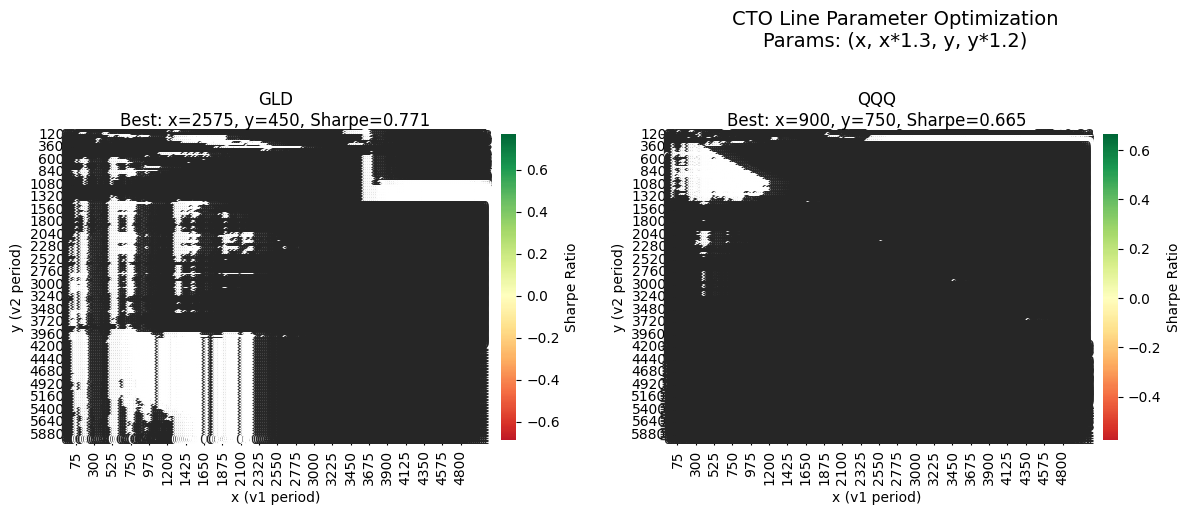

In [8]:
def plot_heatmaps(pivots: Dict[str, pd.DataFrame], best_params: Dict[str, Dict]):
    n_etfs = len(pivots)
    n_cols = 3
    n_rows = (n_etfs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    axes = axes.flatten() if n_etfs > 1 else [axes]
    
    for idx, (symbol, pivot) in enumerate(pivots.items()):
        ax = axes[idx]
        
        sns.heatmap(
            pivot,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            ax=ax,
            cbar_kws={'label': 'Sharpe Ratio'}
        )
        
        best = best_params[symbol]
        ax.set_title(f"{symbol}\nBest: x={int(best['x'])}, y={int(best['y'])}, Sharpe={best['sharpe']:.3f}")
        ax.set_xlabel('x (v1 period)')
        ax.set_ylabel('y (v2 period)')
    
    for idx in range(len(pivots), len(axes)):
        axes[idx].set_visible(False)
    
    plt.suptitle('CTO Line Parameter Optimization\nParams: (x, x*1.3, y, y*1.2)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_heatmaps(all_pivots, all_best)

In [9]:
all_best

{'GLD': {'x': 2575,
  'y': 450,
  'params': (2575, 3347, 450, 540),
  'sharpe': 0.7705789330670775,
  'total_return': 0.05720031261444092},
 'QQQ': {'x': 900,
  'y': 750,
  'params': (900, 1170, 750, 900),
  'sharpe': 0.665162175204598,
  'total_return': 1.1313954591751099}}

In [10]:
summary_data = []
for symbol, best in all_best.items():
    summary_data.append({
        'ETF': symbol,
        'Best x': int(best['x']),
        'Best y': int(best['y']),
        'Params': best['params'],
        'Sharpe': round(best['sharpe'], 4),
        'Total Return': round(best['total_return'], 4)
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Sharpe', ascending=False)
print("\n" + "="*80)
print("OPTIMIZATION SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))
summary_df


OPTIMIZATION SUMMARY
ETF  Best x  Best y                 Params  Sharpe  Total Return
GLD    2575     450 (2575, 3347, 450, 540)  0.7706        0.0572
QQQ     900     750  (900, 1170, 750, 900)  0.6652        1.1314


,ETF,Best x,Best y,Params,Sharpe,Total Return
0,GLD,2575,450,"(2575, 3347, 450, 540)",0.7706,0.0572
1,QQQ,900,750,"(900, 1170, 750, 900)",0.6652,1.1314



Plotting best performing ETF: GLD


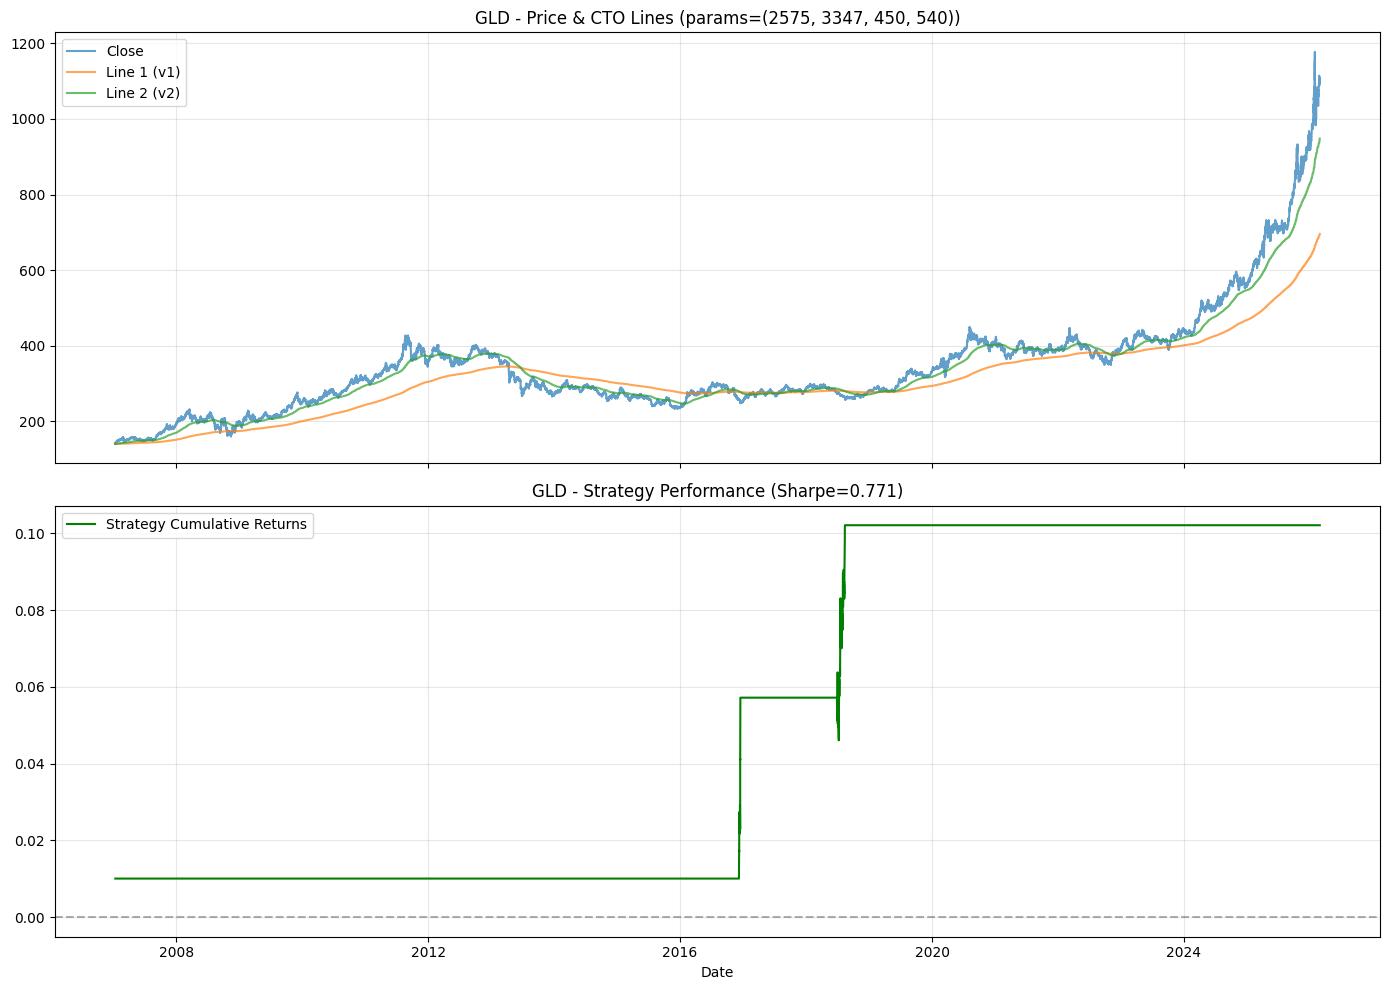

In [11]:
def plot_best_strategy(df_bundle: pd.DataFrame, symbol: str, best_params: Dict):
    ohlcv_df = convert_prefixed_to_ohlcv(df_bundle, symbol)
    params = best_params['params']
    
    strat_df = run_cto_strategy(ohlcv_df, params)
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    ax1.plot(strat_df.index, strat_df['Close'], label='Close', alpha=0.7)
    ax1.plot(strat_df.index, strat_df['Line 1'], label='Line 1 (v1)', alpha=0.7)
    ax1.plot(strat_df.index, strat_df['Line 2'], label='Line 2 (v2)', alpha=0.7)
    ax1.set_title(f'{symbol} - Price & CTO Lines (params={params})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    cum_returns = strat_df['Returns'].cumsum()
    ax2.plot(strat_df.index, cum_returns, label='Strategy Cumulative Returns', color='green')
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.3)
    ax2.set_title(f'{symbol} - Strategy Performance (Sharpe={best_params["sharpe"]:.3f})')
    ax2.set_xlabel('Date')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return strat_df

top_etf = summary_df.iloc[0]['ETF']
print(f"\nPlotting best performing ETF: {top_etf}")
strat_df = plot_best_strategy(df_bundle, top_etf, all_best[top_etf])

In [ ]:
Optimizing GDX...
GDX: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (2875, 3737, 1380, 1656), Sharpe: 0.6874

==================================================
Optimizing GLD...
GLD: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (2575, 3347, 450, 540), Sharpe: 0.7706

==================================================
Optimizing QQQ...
QQQ: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (900, 1170, 750, 900), Sharpe: 0.6652

==================================================
Optimizing SHV...
SHV: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (825, 1072, 900, 1080), Sharpe: 1.3430

==================================================
Optimizing SPY...
SPY: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (700, 910, 390, 468), Sharpe: 0.7027

==================================================
Optimizing TLT...
TLT: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (1575, 2047, 300, 360), Sharpe: 0.7203

==================================================
Optimizing VWO...
VWO: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (500, 650, 180, 216), Sharpe: 0.8265

==================================================
Optimizing XLB...
XLB: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (325, 422, 120, 144), Sharpe: 0.7012

==================================================
Optimizing XLE...
XLE: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (3850, 5005, 210, 252), Sharpe: 0.6348

==================================================
Optimizing XME...
XME: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (1200, 1560, 270, 324), Sharpe: 0.7814



==================================================
Optimizing GDX...
GDX: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (2875, 3737, 1380, 1656), Sharpe: 0.6874

==================================================
Optimizing GLD...
GLD: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (2575, 3347, 450, 540), Sharpe: 0.7706

==================================================
Optimizing QQQ...
QQQ: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (900, 1170, 750, 900), Sharpe: 0.6652

==================================================
Optimizing SHV...
SHV: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (825, 1072, 900, 1080), Sharpe: 1.3430

==================================================
Optimizing SPY...
SPY: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (700, 910, 390, 468), Sharpe: 0.7027

==================================================
Optimizing TLT...
TLT: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (1575, 2047, 300, 360), Sharpe: 0.7203

==================================================
Optimizing VWO...
VWO: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (500, 650, 180, 216), Sharpe: 0.8265

==================================================
Optimizing XLB...
XLB: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (325, 422, 120, 144), Sharpe: 0.7012

==================================================
Optimizing XLE...
XLE: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (3850, 5005, 210, 252), Sharpe: 0.6348

==================================================
Optimizing XME...
XME: 20000 rows, 2007-01-11 09:00:00 to 2017-07-07 10:00:00
Best params: (1200, 1560, 270, 324), Sharpe: 0.7814

    